# BC Playground

```bash
cd ~/robot
nix develop --command jupyter lab
```

In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, numpy as np, torch
import bc_harness as H

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# swap to .../can/ph/low_dim_v15.hdf5 for the harder, longer-horizon task
DATASET = os.path.join("robomimic", "datasets", "lift", "ph", "low_dim_v15.hdf5")
data = H.load_bc_dataset(DATASET)
print(f"{data.n_demos} demos | {data.states.shape[0]} (s,a) pairs | obs_dim={data.obs_dim} act_dim={data.action_dim}")
print("obs keys (concatenated in this order):", data.obs_keys)
print("robot0_eef_pos: meters, robot0_eef_quat: zyzw quat (unitless), robot0_gripper_qpos: meters (prismatic joint finger displacement), object: meters/xyzw quat/meters (eef->cube vector)")

# expected action output
print("position deltas normalized [-1,1], orientation deltas normalized [-1,1], gripper: [-1, 1]: 1 == close, -1 == open")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda | NVIDIA GeForce GTX 1060 6GB
200 demos | 9666 (s,a) pairs | obs_dim=19 act_dim=7
obs keys (concatenated in this order): ('robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'object')
robot0_eef_pos: meters, robot0_eef_quat: zyzw quat (unitless), robot0_gripper_qpos: meters (prismatic joint finger displacement), object: meters/xyzw quat/meters (eef->cube vector)


In [2]:
import torch.nn as nn
import torch.nn.functional as F

class LiftPolicy(nn.Module):
    """train_bc / eval_bc normalize state for you"""
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        layers, d = [], obs_dim

        layers = [nn.Linear(obs_dim, 256), nn.ReLU()]
        layers += [nn.Linear(256, 256), nn.ReLU()]
        layers += [nn.Linear(256, action_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, s):
        return self.net(s)


policy = LiftPolicy(data.obs_dim, data.action_dim)
print(policy)

LiftPolicy(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)


## 2. Train 

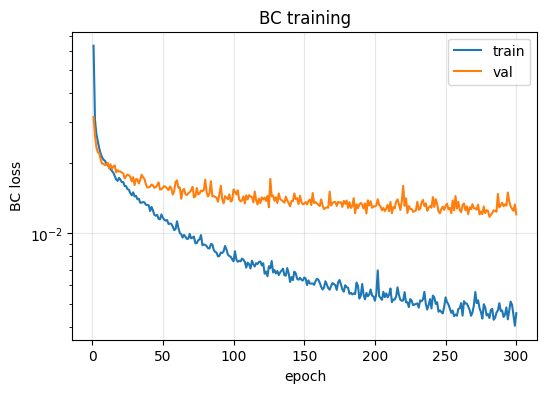

final train loss: 0.00456


In [3]:
history = H.train_bc(
    policy, data,
    epochs=300, batch_size=256, lr=1e-3, weight_decay=0.0,
    device=device, plot=True, plot_every=2, val_frac=0.1,
)
print("final train loss:", round(history["loss"][-1], 5))

## 3. Rollout

In [4]:
env = H.make_env(data, render=True)   # build once; reuse for all rollouts below

ROBOMIMIC WARNING(
    No private macro file found!
    It is recommended to use a private macro file
    To setup, run: python /home/shreshta/robot/robomimic/scripts/setup_macros.py
)


[robosuite WARNING] No private macro file found! (macros.py:57)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)
[robosuite WARNING] To setup, run: python /home/shreshta/robot/.venv/lib/python3.10/site-packages/robosuite/scripts/setup_macros.py (macros.py:59)



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'object', 'robot0_gripper_qpos', 'robot0_eef_quat']
using obs modality: rgb with keys: []


[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


Created environment with name Lift
Action size is 7
ROBOMIMIC WARNING(
    Dataset and installed environment version mismatch!
    Dataset environment version: 1.5.1
    Installed environment version: 1.5.2
)


In [5]:
out = H.rollout(policy, env, data, horizon=400, device=device, img_hw=(256, 256))
print(f"success={out['success']}  length={out['length']}  return={out['total_reward']:.1f}")
H.save_gif(out["frames"], "media/lift_rollout.gif", fps=8, max_frames=24)

success=True  length=40  return=1.0


![lift_rollout](media/lift_rollout.gif)

## 4. Success rate over many episodes (covariate shift)

In [9]:
res = H.evaluate(policy, env, data, n_episodes=20, horizon=400, device=device, render_all=True, img_hw=(128,128))
print(f"success rate over {len(res['episodes'])} episodes: {res['success_rate']*100:.1f}%")
H.save_gif_grid(res["episodes"], "media/lift_grid.gif", ncols=5, fps=6, max_frames=16, scale=0.5)

success rate over 20 episodes: 90.0%


![lift_grid](media/lift_grid.gif)

In [ ]:
## 5. ACT implementation

Compare this closed-loop success rate against the low training loss above. With a
short-horizon task like `lift` a decent MLP gets fairly high; on `can` (longer
horizon) the BC gap is bigger — errors compound (the `O(eps*T^2)` story). That gap
is what Milestone B (ALICE / DAgger) is built to close.